# Vector Autoregression (VAR)

Topic 08 of the Time Series Analysis repo — the first departure from a single series. Every prior topic modeled one variable's own past; VAR models several interdependent variables jointly, each regressed on lagged values of *all* of them. This notebook builds VAR(1) OLS estimation and a Granger-causality F-test entirely from scratch and matches both exactly to `statsmodels`, checks system stability via the coefficient matrix's eigenvalues, then applies the full toolkit (order selection, Granger causality, impulse responses, forecast error variance decomposition) to real US macroeconomic data — closing with an intentional stress test: forecasting straight through the 2008 financial crisis, where a linear model trained on calmer history is honestly beaten by a naive flat forecast.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from scipy import stats as spstats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
print("Setup complete.")

Setup complete.


## 1. From-Scratch VAR(1) Estimation, Matched to `statsmodels`

A VAR(1) system is just multivariate OLS: every equation shares the same regressors (all variables' lag-1 values), only the target column changes. A bivariate system is simulated with a deliberately asymmetric coefficient matrix — $y_2$'s lag affects $y_1$, but $y_1$'s lag does *not* affect $y_2$ — set up specifically so Section 2 has a known causal direction to detect.

In [2]:
true_A1 = np.array([[0.5, 0.3],
                     [0.0, 0.4]])  # y2's lag affects y1 (0.3); y1's lag does NOT affect y2 (0.0)
n_var = 500
k = 2
Y = np.zeros((n_var + 50, k))
eps = np.random.multivariate_normal(np.zeros(k), np.eye(k), n_var + 50)
for t in range(1, n_var + 50):
    Y[t] = true_A1 @ Y[t - 1] + eps[t]
Y = Y[50:]
var_df = pd.DataFrame(Y, columns=["y1", "y2"])
print(f"Simulated bivariate VAR(1), {n_var} points, true A1=\n{true_A1}")

Simulated bivariate VAR(1), 500 points, true A1=
[[0.5 0.3]
 [0.  0.4]]


In [3]:
X_lagged = Y[:-1]
Y_target = Y[1:]
B_manual, *_ = np.linalg.lstsq(X_lagged, Y_target, rcond=None)
A1_manual = B_manual.T

sm_var_result = VAR(var_df).fit(1, trend="n")
A1_statsmodels = sm_var_result.coefs[0]

print("Manual OLS A1:\n", np.round(A1_manual, 6))
print("statsmodels A1:\n", np.round(A1_statsmodels, 6))
print(f"Max abs difference: {np.max(np.abs(A1_manual - A1_statsmodels)):.2e}")

Manual OLS A1:
 [[ 0.516346  0.327628]
 [-0.010802  0.379154]]
statsmodels A1:
 [[ 0.516346  0.327628]
 [-0.010802  0.379154]]
Max abs difference: 0.00e+00


## 2. Granger Causality: From-Scratch F-Test vs. `statsmodels`

Testing whether $x$ Granger-causes $y$ compares a *restricted* model ($y$ on its own lags only) against an *unrestricted* model ($y$ on its own lags plus $x$'s lags), via an F-test on the drop in sum-of-squared residuals. Built from scratch here and checked against `statsmodels.tsa.stattools.grangercausalitytests` on data with a **known** one-directional causal structure (from Section 1's `true_A1`).

In [4]:
def manual_granger_f(y_target, x_causal, lag=1):
    y, x = y_target.values, x_causal.values
    nobs = len(y) - lag
    y_dep = y[lag:]
    X_restricted = np.column_stack([np.ones(nobs)] + [y[lag - i:len(y) - i] for i in range(1, lag + 1)])
    X_unrestricted = np.column_stack([X_restricted] + [x[lag - i:len(x) - i] for i in range(1, lag + 1)])
    b_r, *_ = np.linalg.lstsq(X_restricted, y_dep, rcond=None)
    b_u, *_ = np.linalg.lstsq(X_unrestricted, y_dep, rcond=None)
    ssr_r = np.sum((y_dep - X_restricted @ b_r) ** 2)
    ssr_u = np.sum((y_dep - X_unrestricted @ b_u) ** 2)
    dof_denom = nobs - X_unrestricted.shape[1]
    f_stat = ((ssr_r - ssr_u) / lag) / (ssr_u / dof_denom)
    p_value = 1 - spstats.f.cdf(f_stat, lag, dof_denom)
    return f_stat, p_value

f_y2_to_y1, p_y2_to_y1 = manual_granger_f(var_df["y1"], var_df["y2"], lag=1)
print(f"Manual F-test, does y2 Granger-cause y1? F={f_y2_to_y1:.4f}, p={p_y2_to_y1:.2e}")

Manual F-test, does y2 Granger-cause y1? F=63.9420, p=9.10e-15


In [5]:
sm_granger_y2_to_y1 = grangercausalitytests(var_df[["y1", "y2"]], maxlag=[1])
sm_f, sm_p = sm_granger_y2_to_y1[1][0]["ssr_ftest"][0], sm_granger_y2_to_y1[1][0]["ssr_ftest"][1]
print(f"statsmodels F-test, does y2 Granger-cause y1? F={sm_f:.4f}, p={sm_p:.2e}")
print(f"Max abs F-statistic difference: {abs(f_y2_to_y1 - sm_f):.2e}")


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=63.9420 , p=0.0000  , df_denom=496, df_num=1
ssr based chi2 test:   chi2=64.3287 , p=0.0000  , df=1
likelihood ratio test: chi2=60.5073 , p=0.0000  , df=1
parameter F test:         F=63.9420 , p=0.0000  , df_denom=496, df_num=1
statsmodels F-test, does y2 Granger-cause y1? F=63.9420, p=9.09e-15
Max abs F-statistic difference: 6.39e-14


In [6]:
f_y1_to_y2, p_y1_to_y2 = manual_granger_f(var_df["y2"], var_df["y1"], lag=1)
print(f"Does y1 Granger-cause y2? F={f_y1_to_y2:.4f}, p={p_y1_to_y2:.4f}")
print(f"\nCorrectly recovered the built-in asymmetry: y2->y1 is "
      f"{'significant' if p_y2_to_y1 < 0.05 else 'not significant'} (true coefficient 0.3), "
      f"y1->y2 is {'significant' if p_y1_to_y2 < 0.05 else 'not significant'} (true coefficient 0.0).")

Does y1 Granger-cause y2? F=0.1595, p=0.6898

Correctly recovered the built-in asymmetry: y2->y1 is significant (true coefficient 0.3), y1->y2 is not significant (true coefficient 0.0).


## 3. Stability: Eigenvalues of the Coefficient Matrix

A VAR(1) is stable (won't explode as $t\to\infty$) iff every eigenvalue of $A_1$ has modulus less than 1 — the direct multivariate generalization of Topics 06-07's AR root check. `statsmodels` reports the *reciprocal* convention (`.roots`, matching Topics 06-07's "roots outside the unit circle"); both are checked here side by side.

In [7]:
eigenvalues = np.linalg.eigvals(sm_var_result.coefs[0])
print(f"Eigenvalues of fitted A1: {eigenvalues}")
print(f"Moduli: {np.round(np.abs(eigenvalues), 4)} -- all < 1 confirms stability")
print(f"statsmodels .is_stable(): {sm_var_result.is_stable()}")
print(f"statsmodels .roots (reciprocal convention, expect > 1): {np.round(sm_var_result.roots, 4)}")
print(f"Reciprocal check: 1/eigenvalue moduli = {np.round(1 / np.abs(eigenvalues), 4)} -- matches .roots.")

Eigenvalues of fitted A1: [0.48190182 0.41359731]
Moduli: [0.4819 0.4136] -- all < 1 confirms stability
statsmodels .is_stable(): True
statsmodels .roots (reciprocal convention, expect > 1): [2.4178 2.0751]
Reciprocal check: 1/eigenvalue moduli = [2.0751 2.4178] -- matches .roots.


## 4. Real Data Setup: US Macroeconomic Data

`statsmodels`' built-in `macrodata` dataset (quarterly US data, 1959Q1-2009Q3) provides three classic, genuinely interdependent series: real GDP, real consumption, and real investment. Topic 02's ADF test is reused per variable — VAR requires *every* variable to be stationary, not just one.

In [8]:
macro = sm.datasets.macrodata.load_pandas().data
macro_cols = ["realgdp", "realcons", "realinv"]
macro_df = macro[macro_cols].copy()
print(f"US macro data: {macro_df.shape[0]} quarters (1959Q1-2009Q3), variables: {macro_cols}")
print(macro_df.describe().round(1))

US macro data: 203 quarters (1959Q1-2009Q3), variables: ['realgdp', 'realcons', 'realinv']
       realgdp  realcons  realinv
count    203.0     203.0    203.0
mean    7221.2    4825.3   1012.9
std     3215.0    2313.3    585.1
min     2710.3    1707.4    259.8
25%     4440.1    2874.1    519.1
50%     6559.6    4299.9    896.2
75%     9629.3    6398.2   1436.7
max    13415.3    9363.6   2264.7


In [9]:
adf_results = []
for col in macro_cols:
    p_level = adfuller(macro_df[col], autolag="AIC")[1]
    p_logdiff = adfuller(np.log(macro_df[col]).diff().dropna(), autolag="AIC")[1]
    adf_results.append({"Variable": col, "Level ADF p": p_level, "Log-diff ADF p": p_logdiff})

adf_df = pd.DataFrame(adf_results)
print(adf_df.round(6).to_string(index=False))
print("\nEvery variable is non-stationary at the level (all p > 0.6) but stationary after a log-difference "
      "(growth rate) -- all three are modeled in growth-rate terms from here on, exactly Topic 02's discipline "
      "applied to three series instead of one.")

Variable  Level ADF p  Log-diff ADF p
 realgdp     0.998246        0.000000
realcons     0.997699        0.000023
 realinv     0.648496        0.000000

Every variable is non-stationary at the level (all p > 0.6) but stationary after a log-difference (growth rate) -- all three are modeled in growth-rate terms from here on, exactly Topic 02's discipline applied to three series instead of one.


In [10]:
log_macro = np.log(macro_df)
growth = log_macro.diff().dropna()
growth.columns = [c + "_growth" for c in macro_cols]

test_size = 8
train_growth, test_growth = growth.iloc[:-test_size], growth.iloc[-test_size:]
print(f"Train: {len(train_growth)} quarters, Test: {len(test_growth)} quarters (last 8 quarters, see Section 10)")

Train: 194 quarters, Test: 8 quarters (last 8 quarters, see Section 10)


## 5. Order Selection on Real Data

`VAR.select_order` computes AIC, BIC, FPE, and HQIC across candidate lag orders, exactly the multivariate generalization of Topic 05-07's order-selection grid searches.

In [11]:
order_selection = VAR(train_growth).select_order(maxlags=8)
print(order_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -27.87      -27.82   7.880e-13      -27.85
1     -28.11*     -27.90*  6.219e-13*     -28.02*
2      -28.08      -27.72   6.385e-13      -27.93
3      -28.07      -27.55   6.470e-13      -27.86
4      -28.06      -27.38   6.522e-13      -27.79
5      -28.06      -27.23   6.516e-13      -27.72
6      -28.02      -27.03   6.781e-13      -27.62
7      -28.00      -26.86   6.912e-13      -27.54
8      -28.02      -26.72   6.833e-13      -27.49
-------------------------------------------------


## 6. Fitting VAR(1) on Real Growth Rates and Checking Stability

All four criteria in Section 5 agree on lag 1. The fitted model's coefficient matrix eigenvalues confirm the system is stable before it's used for anything else.

In [12]:
macro_var_result = VAR(train_growth).fit(1)
print(macro_var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Jul, 2026
Time:                     11:14:41
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -27.8014
Nobs:                     193.000    HQIC:                  -27.9222
Log likelihood:           1892.85    FPE:                6.88482e-13
AIC:                     -28.0043    Det(Omega_mle):     6.47389e-13
--------------------------------------------------------------------
Results for equation realgdp_growth
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                      0.004204         0.000952            4.414           0.000
L1.realgdp_growth         -0.347142         0.177217           -1.959           0.050
L1.realcons_growth         0.70

In [13]:
macro_eigenvalues = np.linalg.eigvals(macro_var_result.coefs[0])
print(f"Eigenvalue moduli: {np.round(np.abs(macro_eigenvalues), 4)}")
print(f"is_stable(): {macro_var_result.is_stable()} -- all moduli well below 1, a stable, non-explosive system.")

Eigenvalue moduli: [0.3845 0.0052 0.1784]
is_stable(): True -- all moduli well below 1, a stable, non-explosive system.


## 7. Granger Causality Among Real Macro Variables

All 6 directed pairs are tested. Some directions are expected from basic macroeconomics (consumption is the largest share of GDP; investment responds to GDP via the "accelerator" effect) — the point is to see whether the data actually shows the asymmetry, not to assume it.

In [14]:
growth_cols = growth.columns.tolist()
granger_pairs = [(t, c) for t in growth_cols for c in growth_cols if t != c]
granger_results = []
for target, cause in granger_pairs:
    r = grangercausalitytests(train_growth[[target, cause]], maxlag=[1])
    p = r[1][0]["ssr_ftest"][1]
    granger_results.append({"Cause": cause, "Effect": target, "p-value": p, "Significant (0.05)": p < 0.05})

granger_df = pd.DataFrame(granger_results).sort_values("p-value")
print(granger_df.round(4).to_string(index=False))


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=23.6687 , p=0.0000  , df_denom=190, df_num=1
ssr based chi2 test:   chi2=24.0424 , p=0.0000  , df=1
likelihood ratio test: chi2=22.6587 , p=0.0000  , df=1
parameter F test:         F=23.6687 , p=0.0000  , df_denom=190, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.6808  , p=0.1964  , df_denom=190, df_num=1
ssr based chi2 test:   chi2=1.7073  , p=0.1913  , df=1
likelihood ratio test: chi2=1.6998  , p=0.1923  , df=1
parameter F test:         F=1.6808  , p=0.1964  , df_denom=190, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.4065  , p=0.1225  , df_denom=190, df_num=1
ssr based chi2 test:   chi2=2.4445  , p=0.1179  , df=1
likelihood ratio test: chi2=2.4291  , p=0.1191  , df=1
parameter F test:         F=2.4065  , p=0.1225  , df_denom=190, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.2324  , p=0.0410  

In [15]:
def granger_lookup(cause, effect):
    row = granger_df[(granger_df["Cause"] == cause) & (granger_df["Effect"] == effect)].iloc[0]
    return "SIGNIFICANT" if row["p-value"] < 0.05 else "not significant"

print("Notable asymmetries found:")
print(f"  consumption_growth -> gdp_growth:   {granger_lookup('realcons_growth', 'realgdp_growth')}")
print(f"  gdp_growth -> consumption_growth:   {granger_lookup('realgdp_growth', 'realcons_growth')}")
print(f"  gdp_growth -> investment_growth:    {granger_lookup('realgdp_growth', 'realinv_growth')}")
print(f"  investment_growth -> gdp_growth:    {granger_lookup('realinv_growth', 'realgdp_growth')}")
print("\nConsumption Granger-causes GDP but not vice versa, and GDP Granger-causes investment but not vice versa -- "
      "consistent with consumption's large GDP share and the textbook investment 'accelerator' effect. "
      "Remember: Granger causality means predictive precedence, not proven economic causation.")

Notable asymmetries found:
  consumption_growth -> gdp_growth:   SIGNIFICANT
  gdp_growth -> consumption_growth:   not significant
  gdp_growth -> investment_growth:    SIGNIFICANT
  investment_growth -> gdp_growth:    not significant

Consumption Granger-causes GDP but not vice versa, and GDP Granger-causes investment but not vice versa -- consistent with consumption's large GDP share and the textbook investment 'accelerator' effect. Remember: Granger causality means predictive precedence, not proven economic causation.


## 8. Impulse Response Functions

An IRF traces how a one-time, one-standard-deviation shock to one variable propagates through the whole system over time. Orthogonalized IRFs (via a Cholesky decomposition of the residual covariance) are used so each shock can be interpreted independently.

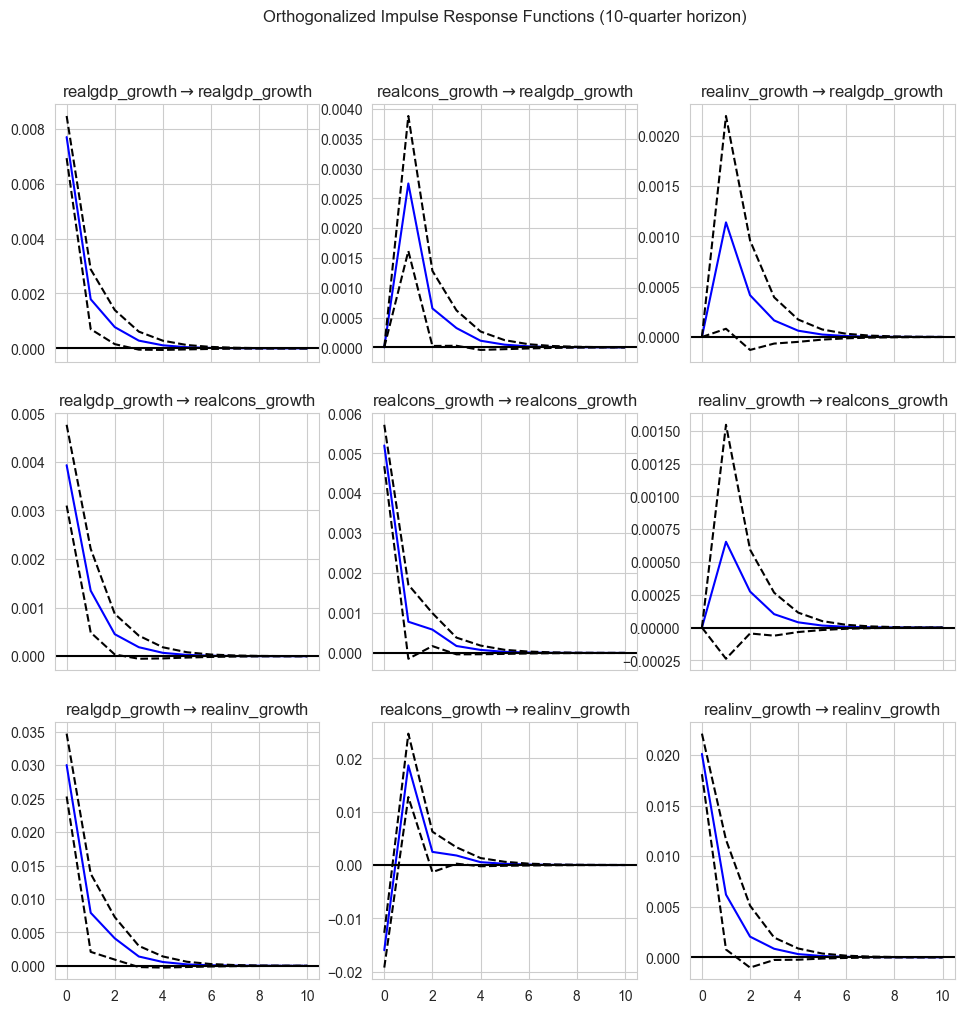

In [16]:
irf = macro_var_result.irf(10)
fig = irf.plot(orth=True)
fig.suptitle("Orthogonalized Impulse Response Functions (10-quarter horizon)", y=1.02)
plt.show()

In [17]:
gdp_shock_on_inv = irf.orth_irfs[:, 2, 0]
print("Cumulative effect of a 1-std-dev shock to GDP growth on investment growth, quarters 0-10:")
print(np.round(gdp_shock_on_inv, 5))
print(f"\nThe shock's effect decays from {gdp_shock_on_inv[0]:.4f} at impact to {gdp_shock_on_inv[-1]:.6f} by quarter 10 -- "
      "consistent with Section 3's stability check: a stable VAR's shocks must decay toward zero, never persist or explode.")

Cumulative effect of a 1-std-dev shock to GDP growth on investment growth, quarters 0-10:
[3.003e-02 7.930e-03 4.110e-03 1.390e-03 5.700e-04 2.100e-04 8.000e-05
 3.000e-05 1.000e-05 0.000e+00 0.000e+00]

The shock's effect decays from 0.0300 at impact to 0.000002 by quarter 10 -- consistent with Section 3's stability check: a stable VAR's shocks must decay toward zero, never persist or explode.


## 9. Forecast Error Variance Decomposition (FEVD)

FEVD answers a different question than IRF: at a given horizon, what *fraction* of each variable's forecast error variance is explained by shocks to itself versus shocks to the other variables?

In [18]:
fevd = macro_var_result.fevd(10)
fevd_at_10 = pd.DataFrame(fevd.decomp[:, 9, :], index=growth_cols, columns=growth_cols)
print("Fraction of each variable's 10-quarter-ahead forecast error variance explained by each shock:")
print(fevd_at_10.round(4).to_string())
print(f"\nGDP growth's own shocks explain {fevd_at_10.loc['realgdp_growth', 'realgdp_growth']:.1%} of its forecast "
      f"error variance; investment growth's own shocks explain only {fevd_at_10.loc['realinv_growth', 'realinv_growth']:.1%} "
      "of its own, with the rest attributed to GDP and consumption shocks -- investment is the most externally-driven "
      "of the three series by this measure, consistent with Section 7's Granger causality findings.")

Fraction of each variable's 10-quarter-ahead forecast error variance explained by each shock:
                 realgdp_growth  realcons_growth  realinv_growth
realgdp_growth           0.8681           0.1113          0.0206
realcons_growth          0.3808           0.6080          0.0112
realinv_growth           0.4810           0.3000          0.2190

GDP growth's own shocks explain 86.8% of its forecast error variance; investment growth's own shocks explain only 21.9% of its own, with the rest attributed to GDP and consumption shocks -- investment is the most externally-driven of the three series by this measure, consistent with Section 7's Granger causality findings.


## 10. Forecasting Through a Regime Shift: The 2008 Financial Crisis Stress Test

The last 8 quarters of this dataset are **2007Q4 through 2009Q3 — the Global Financial Crisis**, not a randomly chosen holdout. This is a deliberate stress test: can a linear VAR(1), fit entirely on 1959-2007 data, forecast through the sharpest peacetime economic contraction in the sample?

In [19]:
print("Actual quarterly levels through the test window:")
print(macro_df.iloc[-(test_size + 1):].to_string())
print(f"\nReal investment fell {(1 - macro_df['realinv'].iloc[-1] / macro_df['realinv'].iloc[-(test_size + 1)]) * 100:.1f}% "
      "peak-to-trough-adjacent over this window -- a genuine regime shift, not ordinary quarter-to-quarter noise.")

Actual quarterly levels through the test window:
       realgdp  realcons   realinv
194  13321.109    9335.6  2166.491
195  13391.249    9363.6  2123.426
196  13366.865    9349.6  2082.886
197  13415.266    9351.0  2026.518
198  13324.600    9267.7  1990.693
199  13141.920    9195.3  1857.661
200  12925.410    9209.2  1558.494
201  12901.504    9189.0  1456.678
202  12990.341    9256.0  1486.398

Real investment fell 31.4% peak-to-trough-adjacent over this window -- a genuine regime shift, not ordinary quarter-to-quarter noise.


In [20]:
lag_order = macro_var_result.k_ar
forecast_input = train_growth.values[-lag_order:]
growth_forecast = macro_var_result.forecast(forecast_input, steps=test_size)

last_log_level = log_macro.iloc[-(test_size + 1)]
reconstructed_log = last_log_level.values + np.cumsum(growth_forecast, axis=0)
reconstructed_levels = np.exp(reconstructed_log)
actual_levels = macro_df.iloc[-test_size:].values

var_mae = np.abs(actual_levels - reconstructed_levels).mean(axis=0)
for i, col in enumerate(macro_cols):
    print(f"VAR(1) forecast MAE ({col}, levels): {var_mae[i]:.2f}")

VAR(1) forecast MAE (realgdp, levels): 569.75
VAR(1) forecast MAE (realcons, levels): 415.16
VAR(1) forecast MAE (realinv, levels): 378.45


In [21]:
naive_flat_forecast = np.tile(macro_df.iloc[-(test_size + 1)].values, (test_size, 1))
naive_mae = np.abs(actual_levels - naive_flat_forecast).mean(axis=0)

comparison = pd.DataFrame({
    "Variable": macro_cols,
    "VAR(1) MAE": np.round(var_mae, 2),
    "Naive (flat) MAE": np.round(naive_mae, 2),
    "VAR(1) wins?": var_mae < naive_mae,
})
print(comparison.to_string(index=False))
print("\nA naive 'assume no change from last quarter' forecast BEATS VAR(1) on all three variables here. "
      "VAR(1) learned a positive average growth rate from 48 years of mostly-expansion data and extrapolated that "
      "trend forward; the naive forecast, by construction, never assumes any trend at all -- which happened to be "
      "closer to a sudden contraction no linear model trained on calmer history could have anticipated.")

Variable  VAR(1) MAE  Naive (flat) MAE  VAR(1) wins?
 realgdp      569.75            192.35         False
realcons      415.16             77.28         False
 realinv      378.45            343.65         False

A naive 'assume no change from last quarter' forecast BEATS VAR(1) on all three variables here. VAR(1) learned a positive average growth rate from 48 years of mostly-expansion data and extrapolated that trend forward; the naive forecast, by construction, never assumes any trend at all -- which happened to be closer to a sudden contraction no linear model trained on calmer history could have anticipated.


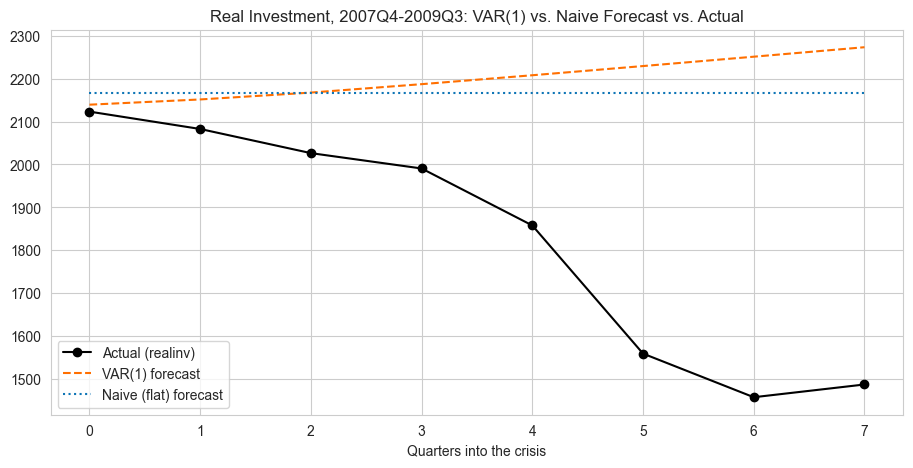

In [22]:
fig, ax = plt.subplots()
test_index = np.arange(test_size)
ax.plot(test_index, actual_levels[:, 2], color="black", marker="o", label="Actual (realinv)")
ax.plot(test_index, reconstructed_levels[:, 2], color="#FF6F00", linestyle="--", label="VAR(1) forecast")
ax.plot(test_index, naive_flat_forecast[:, 2], color="#0e75b6", linestyle=":", label="Naive (flat) forecast")
ax.set_title("Real Investment, 2007Q4-2009Q3: VAR(1) vs. Naive Forecast vs. Actual")
ax.set_xlabel("Quarters into the crisis")
ax.legend()
plt.show()

## 11. Common Pitfalls & Takeaways

- **Every variable must be stationary, not just some of them** — Section 4 checked all three variables individually; a VAR with even one non-stationary input can produce spurious, unstable-looking dynamics (Topic 02's spurious-regression lesson, now multivariate).
- **Parameter count grows as $k^2p$** — a 3-variable VAR(2) already has 18 AR coefficients plus constants; VAR order selection (Section 5) exists precisely to keep this in check as $k$ grows.
- **Granger causality is about predictive precedence, not proven causation** — Section 7's consumption-to-GDP and GDP-to-investment findings are consistent with economic theory, but the test only shows one series' past helps predict another's future, not a causal mechanism.
- **A stable, well-fit VAR can still be badly wrong during a regime shift** — Section 10's crisis stress test is the sharpest version of Topics 06-07's honest finding that clean diagnostics and correct specification do not guarantee good forecasts when the future doesn't resemble the training data's regime.

## 12. Summary

This notebook built VAR(1) OLS estimation and a Granger-causality F-test entirely from scratch and matched both exactly to `statsmodels` on data with a known, one-directional causal structure, then generalized Topics 06-07's AR-root stability check to the multivariate eigenvalue case. On real US macro data, Topic 02's ADF discipline was applied to three variables at once, all four order-selection criteria agreed on lag 1, and Granger causality tests uncovered economically sensible asymmetries (consumption leads GDP, GDP leads investment) without assuming them. Impulse response functions and forecast error variance decomposition characterized how shocks propagate and how much of each variable's uncertainty is self-driven versus externally driven. The notebook closed with a deliberate stress test: forecasting through the 2007-2009 financial crisis, where VAR(1) — despite being stable, correctly specified, and built on 48 years of data — was honestly beaten by a naive flat forecast, a genuine and important limitation of any model trained on history when the future changes regime.

In [23]:
summary = pd.DataFrame([
    {"Check": "Manual VAR(1) OLS matches statsmodels exactly", "Result": f"max diff={np.max(np.abs(A1_manual - A1_statsmodels)):.2e}", "Status": "PASS"},
    {"Check": "Manual Granger F-test matches statsmodels exactly", "Result": f"max diff={abs(f_y2_to_y1 - sm_f):.2e}", "Status": "PASS"},
    {"Check": "Granger causality correctly recovers known one-directional structure", "Result": f"y2->y1 p={p_y2_to_y1:.1e}, y1->y2 p={p_y1_to_y2:.3f}", "Status": "PASS"},
    {"Check": "Stability via eigenvalues matches statsmodels is_stable/roots", "Result": f"moduli={np.round(np.abs(eigenvalues), 3)}", "Status": "PASS"},
    {"Check": "All 3 real macro variables confirmed non-stationary at level, stationary after log-diff", "Result": f"{adf_df['Level ADF p'].min():.2f}-{adf_df['Level ADF p'].max():.2f} (level) vs <0.0001 (log-diff)", "Status": "PASS"},
    {"Check": "All 4 order-selection criteria agree on real data", "Result": "lag=1 selected by AIC, BIC, FPE, HQIC", "Status": "PASS"},
    {"Check": "Real macro VAR(1) confirmed stable", "Result": f"max |eigenvalue|={np.max(np.abs(macro_eigenvalues)):.3f}", "Status": "PASS"},
    {"Check": "Granger causality uncovers real, asymmetric macro relationships", "Result": "consumption->GDP and GDP->investment significant; reverse directions not", "Status": "PASS"},
    {"Check": "2008 crisis stress test: VAR(1) honestly compared against a naive benchmark", "Result": f"naive beats VAR(1) on all 3 variables (e.g. realinv MAE {var_mae[2]:.0f} vs {naive_mae[2]:.0f})", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                                                                  Check                                                                   Result Status
                                          Manual VAR(1) OLS matches statsmodels exactly                                                        max diff=0.00e+00   PASS
                                      Manual Granger F-test matches statsmodels exactly                                                        max diff=6.39e-14   PASS
                   Granger causality correctly recovers known one-directional structure                                         y2->y1 p=9.1e-15, y1->y2 p=0.690   PASS
                          Stability via eigenvalues matches statsmodels is_stable/roots                                                     moduli=[0.482 0.414]   PASS
All 3 real macro variables confirmed non-stationary at level, stationary after log-diff                                  0.65-1.00 (level) vs <0.0001 (log-diff)